In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [2]:
train = pd.read_csv('../data/train (1).csv')
test  = pd.read_csv('../data/test (1).csv')

print("Data loaded successfully ✅")

Data loaded successfully ✅


In [3]:
print("Train shape:", train.shape)
print("Test shape: ", test.shape)


Train shape: (1460, 81)
Test shape:  (1459, 80)


In [4]:
print("Data types in Train:")
print(train.dtypes.value_counts())

Data types in Train:
object     43
int64      35
float64     3
Name: count, dtype: int64


In [5]:
print("SalePrice Statistics:")
print(train['SalePrice'].describe())

SalePrice Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [6]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [7]:
numerical_cols = train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print("\nNumerical:", numerical_cols)
print("\nCategorical:", categorical_cols)

Numerical columns: 38
Categorical columns: 43

Numerical: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Kitche

In [8]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
# Columns with more than 50% missing values are useless — drop them
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'Id']

train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)

print("Dropped columns ✅")
print("New Train shape:", train.shape)
print("New Test shape:", test.shape)

Dropped columns ✅
New Train shape: (1460, 75)
New Test shape: (1459, 74)


In [10]:
# For categorical columns — missing usually means "None" (no garage, no basement etc.)
categorical_fill = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
                    'BsmtFinType2', 'MasVnrType']

for col in categorical_fill:
    train[col].fillna('None', inplace=True)
    test[col].fillna('None', inplace=True)

print("Categorical missing values filled ✅")

Categorical missing values filled ✅


In [11]:
# LotFrontage — fill with median grouped by Neighborhood (smarter than global median)
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# GarageYrBlt and MasVnrArea — fill with 0
for col in ['GarageYrBlt', 'MasVnrArea']:
    train[col].fillna(0, inplace=True)
    test[col].fillna(0, inplace=True)

# Electrical — fill with most frequent value
train['Electrical'].fillna(train['Electrical'].mode()[0], inplace=True)
test['Electrical'].fillna(test['Electrical'].mode()[0], inplace=True)

print("Numerical missing values filled ✅")

Numerical missing values filled ✅


In [12]:
# Fill any remaining numerical nulls in test with median
for col in test.select_dtypes(include=['int64','float64']).columns:
    test[col].fillna(test[col].median(), inplace=True)

# Fill any remaining categorical nulls in test with mode
for col in test.select_dtypes(include=['object']).columns:
    test[col].fillna(test[col].mode()[0], inplace=True)

print("Remaining missing values handled ✅")

Remaining missing values handled ✅


In [13]:
print("Missing values in Train:", train.isnull().sum().sum())
print("Missing values in Test: ", test.isnull().sum().sum())

Missing values in Train: 0
Missing values in Test:  0


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col]  = le.fit_transform(test[col].astype(str))

print("Categorical encoding done ✅")
print("Train shape:", train.shape)
print("Test shape: ", test.shape)

Categorical encoding done ✅
Train shape: (1460, 75)
Test shape:  (1459, 74)


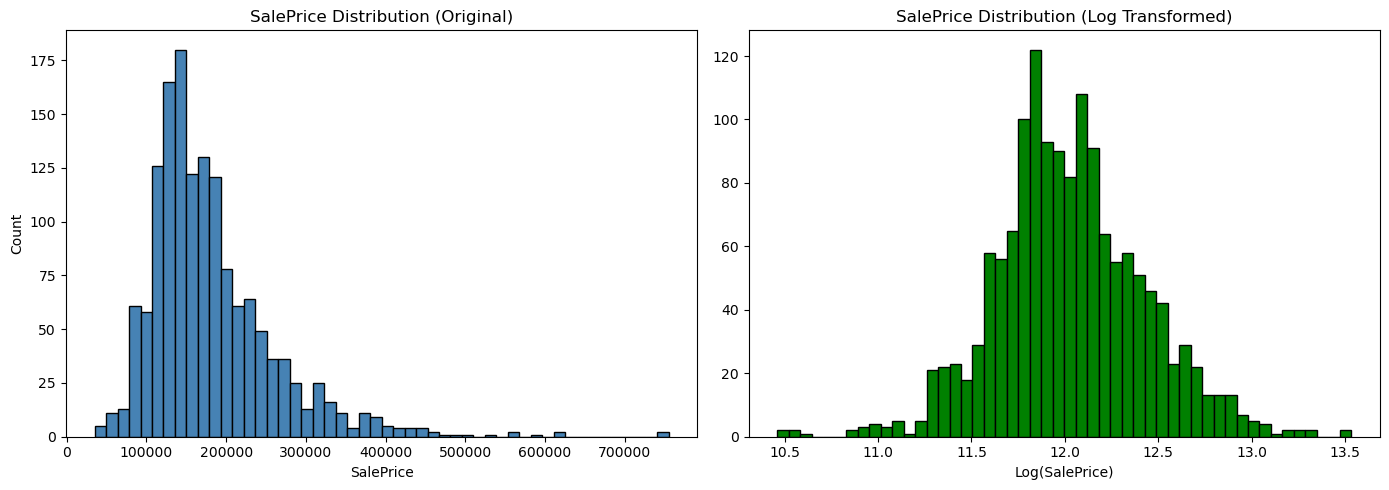

Plot saved ✅


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — original distribution
axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('SalePrice Distribution (Original)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Count')

# Right plot — log transformed
import numpy as np
axes[1].hist(np.log1p(train['SalePrice']), bins=50, color='green', edgecolor='black')
axes[1].set_title('SalePrice Distribution (Log Transformed)')
axes[1].set_xlabel('Log(SalePrice)')

plt.tight_layout()
plt.savefig('../models/saleprice_distribution.png')
plt.show()
print("Plot saved ✅")

Top 10 correlated features with SalePrice:
SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
ExterQual      0.636884
GarageArea     0.623431
TotalBsmtSF    0.613581
1stFlrSF       0.605852
BsmtQual       0.593734
KitchenQual    0.589189
FullBath       0.560664
Name: SalePrice, dtype: float64


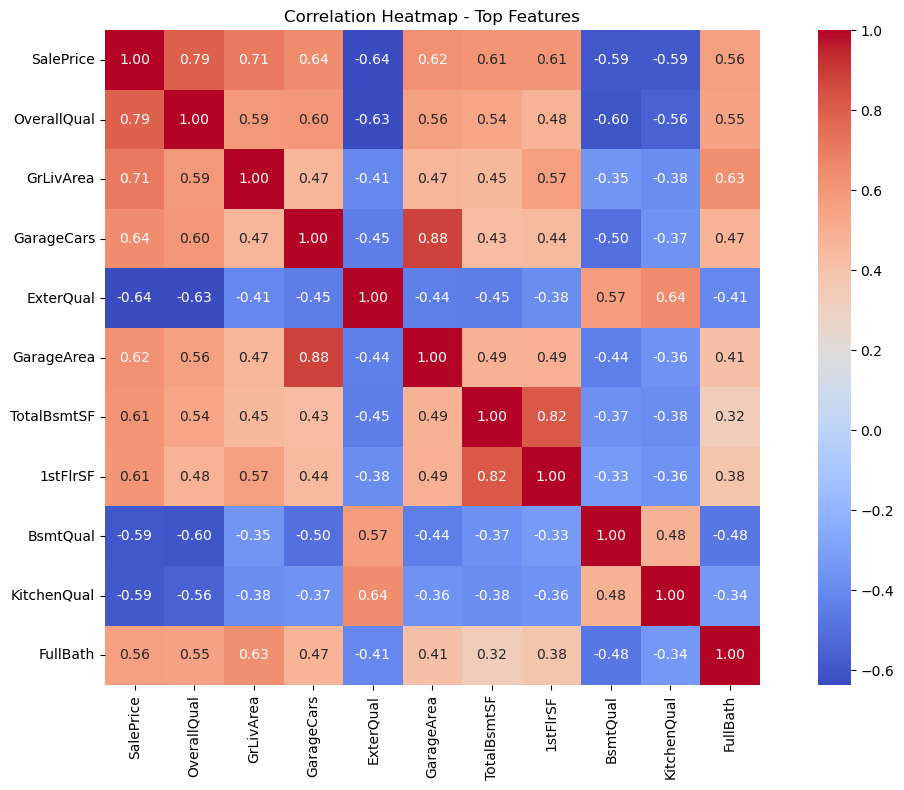

Heatmap saved ✅


In [16]:
# Find top 10 features most correlated with SalePrice
corr_matrix = train.corr()
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(11)
print("Top 10 correlated features with SalePrice:")
print(top_corr)

# Plot heatmap
top_features = top_corr.index.tolist()
plt.figure(figsize=(12, 8))
sns.heatmap(train[top_features].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            square=True)
plt.title('Correlation Heatmap - Top Features')
plt.tight_layout()
plt.savefig('../models/correlation_heatmap.png')
plt.show()
print("Heatmap saved ✅")

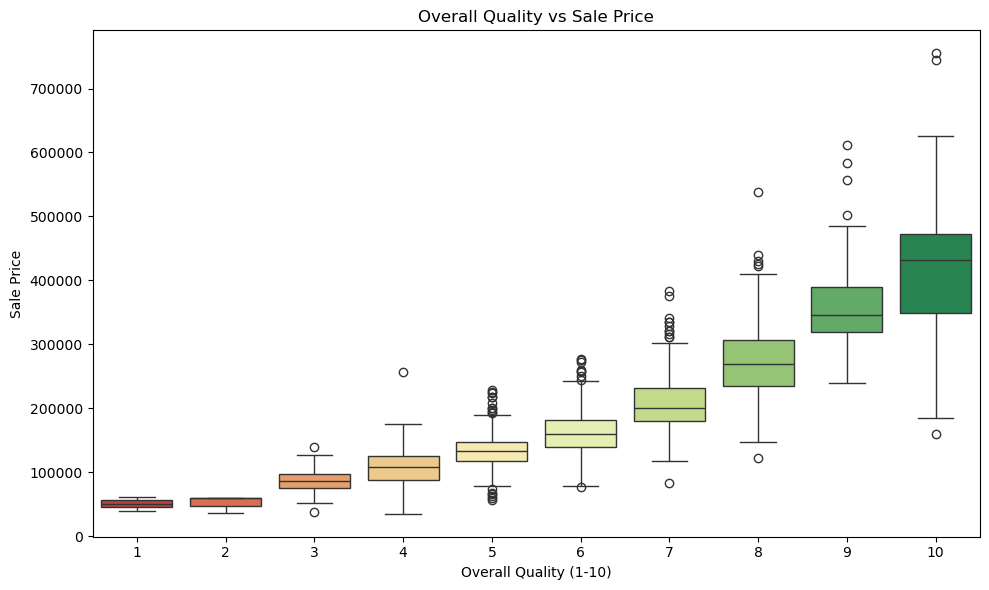

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=train, palette='RdYlGn')
plt.title('Overall Quality vs Sale Price')
plt.xlabel('Overall Quality (1-10)')
plt.ylabel('Sale Price')
plt.tight_layout()
plt.savefig('../models/quality_vs_price.png')
plt.show()

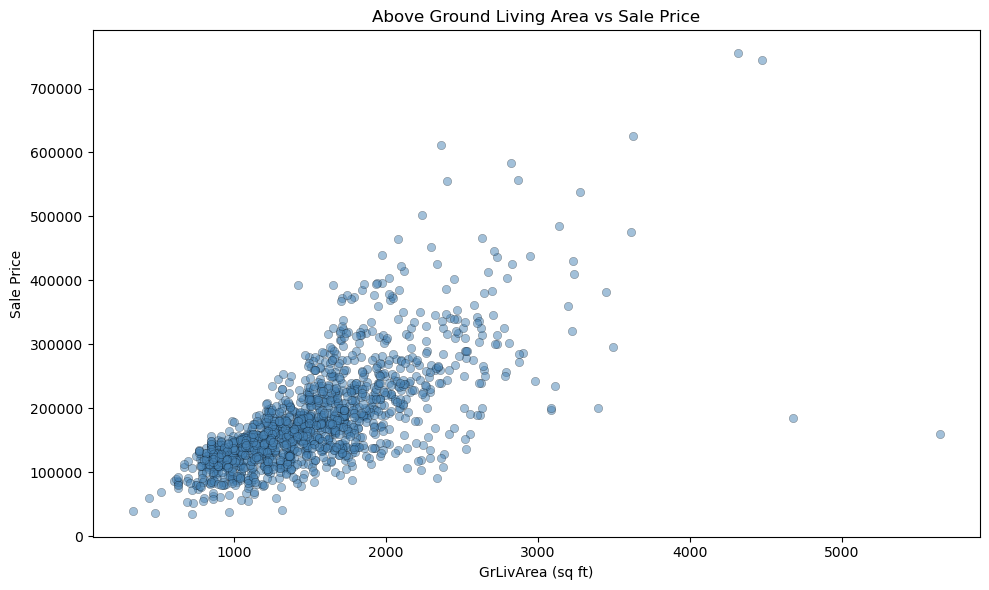

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(train['GrLivArea'], train['SalePrice'], 
            alpha=0.5, color='steelblue', edgecolors='black', linewidths=0.3)
plt.title('Above Ground Living Area vs Sale Price')
plt.xlabel('GrLivArea (sq ft)')
plt.ylabel('Sale Price')
plt.tight_layout()
plt.savefig('../models/livarea_vs_price.png')
plt.show()

In [19]:
# Houses with very large area but low price are outliers — dangerous for model
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print(f"Outliers found: {len(outliers)}")
print(outliers[['GrLivArea', 'SalePrice']])

# Remove these outliers
train = train.drop(outliers.index)
print(f"\nOutliers removed ✅")
print(f"New Train shape: {train.shape}")

Outliers found: 2
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000

Outliers removed ✅
New Train shape: (1458, 75)


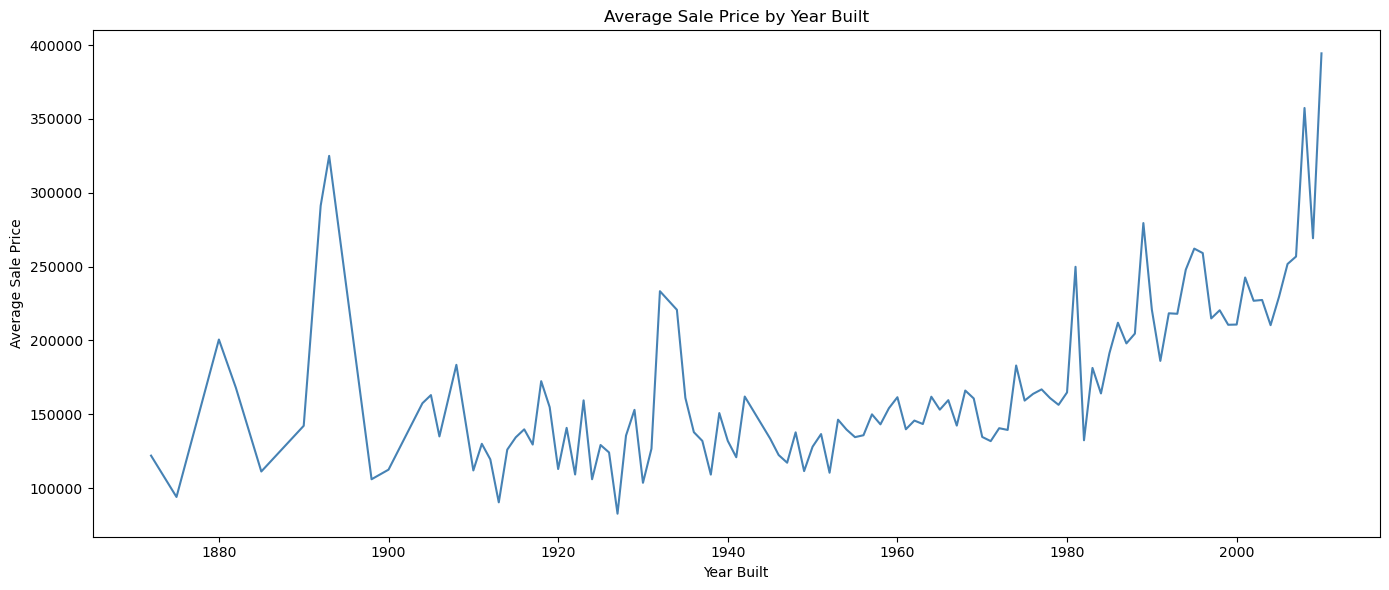

In [20]:
plt.figure(figsize=(14, 6))
train.groupby('YearBuilt')['SalePrice'].mean().plot(kind='line', color='steelblue')
plt.title('Average Sale Price by Year Built')
plt.xlabel('Year Built')
plt.ylabel('Average Sale Price')
plt.tight_layout()
plt.savefig('../models/yearbuilt_vs_price.png')
plt.show()

In [21]:
# WHY: These new features capture combined information better than individual columns

# Total area of house
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF']  = test['TotalBsmtSF']  + test['1stFlrSF']  + test['2ndFlrSF']

# Total bathrooms
train['TotalBath'] = (train['FullBath'] + train['BsmtFullBath'] + 
                      0.5 * (train['HalfBath'] + train['BsmtHalfBath']))
test['TotalBath']  = (test['FullBath']  + test['BsmtFullBath']  + 
                      0.5 * (test['HalfBath']  + test['BsmtHalfBath']))

# House age when sold
train['HouseAge']    = train['YrSold'] - train['YearBuilt']
test['HouseAge']     = test['YrSold']  - test['YearBuilt']

# Was the house remodeled?
train['IsRemodeled'] = (train['YearRemodAdd'] != train['YearBuilt']).astype(int)
test['IsRemodeled']  = (test['YearRemodAdd']  != test['YearBuilt']).astype(int)

# Total porch area
train['TotalPorch'] = (train['OpenPorchSF'] + train['EnclosedPorch'] + 
                       train['3SsnPorch'] + train['ScreenPorch'])
test['TotalPorch']  = (test['OpenPorchSF']  + test['EnclosedPorch']  + 
                       test['3SsnPorch']  + test['ScreenPorch'])

print("New features created ✅")
print("Train shape:", train.shape)

New features created ✅
Train shape: (1458, 80)


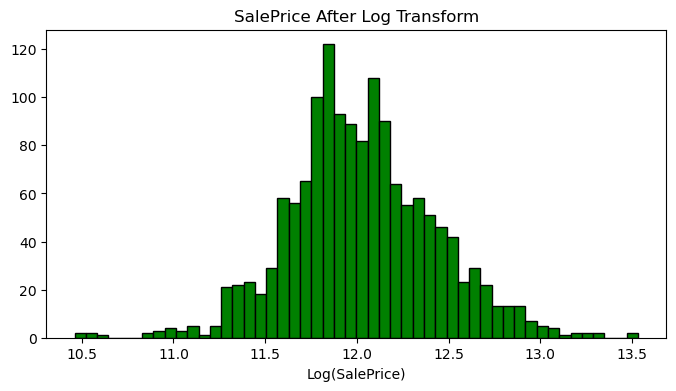

SalePrice skewness after log transform: 0.1216


In [22]:
# WHY: Linear models assume normal distribution. 
# Log transform makes SalePrice normally distributed = better model performance

train['SalePrice'] = np.log1p(train['SalePrice'])

plt.figure(figsize=(8,4))
plt.hist(train['SalePrice'], bins=50, color='green', edgecolor='black')
plt.title('SalePrice After Log Transform')
plt.xlabel('Log(SalePrice)')
plt.show()

print("SalePrice skewness after log transform:", round(train['SalePrice'].skew(), 4))

In [23]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = train.drop(columns=['SalePrice'])
y = train['SalePrice']

# Split into train and validation sets
# WHY: We need unseen data to evaluate model honestly
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")

X_train shape: (1166, 79)
X_val shape:   (292, 79)
y_train shape: (1166,)
y_val shape:   (292,)


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# WHY: Always start with simplest model as baseline
# If complex models don't beat this, something is wrong

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_lr   = r2_score(y_val, y_pred_lr)

print("=== Linear Regression Results ===")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R2   : {r2_lr:.4f}")

=== Linear Regression Results ===
RMSE : 0.1278
R2   : 0.9031


In [25]:
from sklearn.ensemble import RandomForestRegressor

# WHY: Random Forest handles non-linearity and feature interactions better
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf   = r2_score(y_val, y_pred_rf)

print("=== Random Forest Results ===")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R2   : {r2_rf:.4f}")

=== Random Forest Results ===
RMSE : 0.1426
R2   : 0.8794


In [26]:
from xgboost import XGBRegressor

# WHY: XGBoost is state of the art for tabular data
# Wins most Kaggle competitions involving structured data

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_val)

rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb   = r2_score(y_val, y_pred_xgb)

print("=== XGBoost Results ===")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R2   : {r2_xgb:.4f}")

=== XGBoost Results ===
RMSE : 0.1232
R2   : 0.9100


In [27]:
print("=" * 40)
print("       MODEL COMPARISON SUMMARY")
print("=" * 40)
print(f"{'Model':<20} {'RMSE':>8} {'R2':>8}")
print("-" * 40)
print(f"{'Linear Regression':<20} {rmse_lr:>8.4f} {r2_lr:>8.4f}")
print(f"{'Random Forest':<20} {rmse_rf:>8.4f} {r2_rf:>8.4f}")
print(f"{'XGBoost':<20} {rmse_xgb:>8.4f} {r2_xgb:>8.4f}")
print("=" * 40)
print("\n✅ Lower RMSE = Better | Higher R2 = Better")

       MODEL COMPARISON SUMMARY
Model                    RMSE       R2
----------------------------------------
Linear Regression      0.1278   0.9031
Random Forest          0.1426   0.8794
XGBoost                0.1232   0.9100

✅ Lower RMSE = Better | Higher R2 = Better


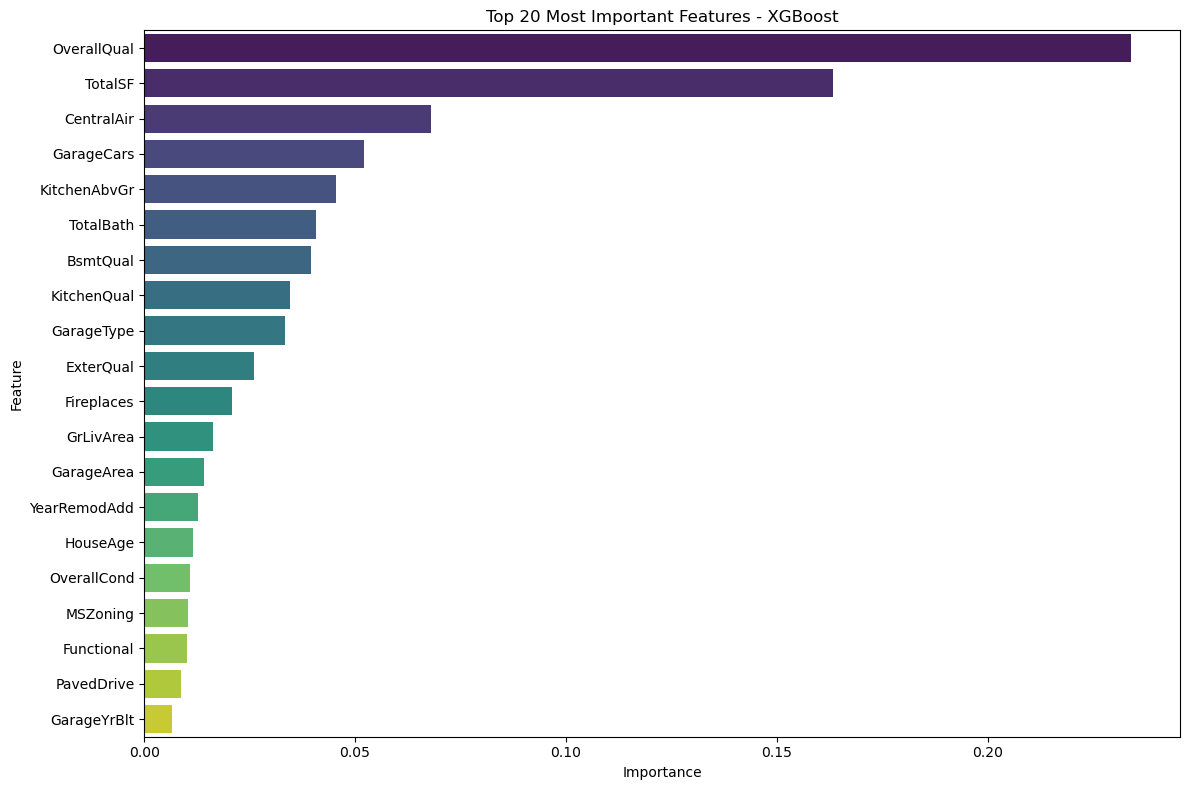


Top 10 Most Important Features:
     Feature  Importance
 OverallQual    0.233811
     TotalSF    0.163195
  CentralAir    0.067877
  GarageCars    0.052149
KitchenAbvGr    0.045377
   TotalBath    0.040640
    BsmtQual    0.039609
 KitchenQual    0.034671
  GarageType    0.033456
   ExterQual    0.026015


In [28]:
# WHY: Understand which features drive predictions most
# This is what interviewers ALWAYS ask about

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 20 Most Important Features - XGBoost')
plt.tight_layout()
plt.savefig('../models/feature_importance.png')
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

In [29]:
from sklearn.model_selection import RandomizedSearchCV

# WHY: Default parameters are never optimal
# RandomizedSearchCV is faster than GridSearchCV for large search spaces

param_grid = {
    'n_estimators'    : [500, 1000, 1500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator   = xgb_base,
    param_distributions = param_grid,
    n_iter      = 30,
    scoring     = 'neg_root_mean_squared_error',
    cv          = 5,
    verbose     = 1,
    random_state= 42,
    n_jobs      = -1
)

random_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters Found:
{'subsample': 0.6, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


In [30]:
best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_val)

rmse_tuned = np.sqrt(mean_squared_error(y_val, y_pred_tuned))
r2_tuned   = r2_score(y_val, y_pred_tuned)

print("=== Tuned XGBoost Results ===")
print(f"RMSE : {rmse_tuned:.4f}")
print(f"R2   : {r2_tuned:.4f}")

print("\n=== Improvement ===")
print(f"RMSE before tuning : {rmse_xgb:.4f}")
print(f"RMSE after tuning  : {rmse_tuned:.4f}")
print(f"Improvement        : {((rmse_xgb - rmse_tuned)/rmse_xgb * 100):.2f}%")

=== Tuned XGBoost Results ===
RMSE : 0.1168
R2   : 0.9191

=== Improvement ===
RMSE before tuning : 0.1232
RMSE after tuning  : 0.1168
Improvement        : 5.20%


In [31]:
import pickle

# WHY: We save the model so we don't retrain every time
# Deployment loads this saved file to make predictions instantly

model_path = '../models/house_price_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"Model saved to {model_path} ✅")

# Verify it loads correctly
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_val[:5])
print(f"\nTest predictions (log scale): {test_pred}")
print(f"Test predictions (actual $) : {np.expm1(test_pred).astype(int)}")
print("\nModel loads and predicts correctly ✅")

Model saved to ../models/house_price_model.pkl ✅

Test predictions (log scale): [12.262405 11.489484 11.608375 12.006053 12.687196]
Test predictions (actual $) : [211588  97682 110014 163741 323577]

Model loads and predicts correctly ✅


In [32]:
# WHY: Streamlit app needs exact same feature names and order
# as training data — this file ensures that

feature_names = X_train.columns.tolist()

with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print(f"Total features saved: {len(feature_names)}")
print("Feature names saved ✅")

Total features saved: 79
Feature names saved ✅


In [33]:
# Align test columns with training columns
test_final = test[feature_names]

# Predict on test set
test_predictions = best_model.predict(test_final)

# Convert back from log scale to actual price
test_predictions_actual = np.expm1(test_predictions)

# Load sample submission
submission = pd.read_csv('../data/sample_submission.csv')
submission['SalePrice'] = test_predictions_actual

# Save submission
submission.to_csv('../models/submission.csv', index=False)

print("Submission file created ✅")
print(submission.head())
print(f"\nPredicted price range: ${submission['SalePrice'].min():,.0f} to ${submission['SalePrice'].max():,.0f}")

Submission file created ✅
     Id      SalePrice
0  1461  123310.312500
1  1462  160701.390625
2  1463  181833.671875
3  1464  188754.468750
4  1465  187434.406250

Predicted price range: $50,409 to $633,487
